# Notebook de pretraitement d'images

Ce notebook realise:
- Redimensionnement des images
- Conversion couleur (RGB, HSV ou grayscale)
- Filtrage anti-bruit (gaussian, median, bilateral)
- Analyse d'histogrammes sur des echantillons
- Rapport JSON final du pretraitement

In [9]:
from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('Imports OK')

Imports OK


In [10]:
# Configuration
INPUT_DIR = Path('../data/raw')
OUTPUT_DIR = Path('../data/processed')
HIST_DIR = OUTPUT_DIR / 'histograms'

TARGET_SIZE = (224, 224)  # (width, height)
COLOR_MODE = 'hsv'        # 'rgb' | 'hsv' | 'gray'
DENOISE_MODE = 'median'   # 'none' | 'gaussian' | 'median' | 'bilateral'
HIST_SAMPLES = 10
SEED = 42

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HIST_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input dir: {INPUT_DIR.resolve()}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')

Input dir: C:\Users\louay\OneDrive\Desktop\computer vision\data\raw
Output dir: C:\Users\louay\OneDrive\Desktop\computer vision\data\processed


In [11]:
def list_image_files(root: Path):
    return [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS]


def apply_denoise(image_bgr, mode: str):
    if mode == 'none':
        return image_bgr
    if mode == 'gaussian':
        return cv2.GaussianBlur(image_bgr, (5, 5), 0)
    if mode == 'median':
        return cv2.medianBlur(image_bgr, 5)
    if mode == 'bilateral':
        return cv2.bilateralFilter(image_bgr, 9, 75, 75)
    raise ValueError(f'Unsupported denoise mode: {mode}')


def convert_color(image_bgr, mode: str):
    if mode == 'rgb':
        return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    if mode == 'hsv':
        return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    if mode == 'gray':
        return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    raise ValueError(f'Unsupported color mode: {mode}')


def save_image(image, out_path: Path, mode: str):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if mode == 'gray':
        cv2.imwrite(str(out_path), image)
    elif mode == 'rgb':
        cv2.imwrite(str(out_path), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    else:
        # Save HSV matrix directly for processing pipelines.
        cv2.imwrite(str(out_path), image)


def plot_histogram(image, image_name: str, mode: str, save_path: Path):
    plt.figure(figsize=(9, 4))

    if mode == 'gray':
        plt.hist(image.ravel(), bins=256, range=(0, 256), color='black')
        plt.title(f'Histogram (grayscale) - {image_name}')
        plt.xlabel('Intensity')
        plt.ylabel('Pixel count')
    else:
        channel_colors = ['r', 'g', 'b']
        for i, c in enumerate(channel_colors):
            hist = cv2.calcHist([image], [i], None, [256], [0, 256])
            plt.plot(hist, color=c, label=f'C{i+1}')
        plt.title(f'Histogram ({mode.upper()}) - {image_name}')
        plt.xlabel('Value')
        plt.ylabel('Pixel count')
        plt.legend()

    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path)
    plt.close()

In [14]:
# Execution du pretraitement
if not INPUT_DIR.exists():
    raise FileNotFoundError(f'Input directory not found: {INPUT_DIR.resolve()}')

image_paths = list_image_files(INPUT_DIR)
if not image_paths:
    raise RuntimeError(f'No images found in: {INPUT_DIR.resolve()}')

np.random.seed(SEED)
sample_indices = set(np.random.choice(len(image_paths), size=min(HIST_SAMPLES, len(image_paths)), replace=False))

processed_count = 0
failed_files = []

for idx, image_path in enumerate(image_paths):
    rel = image_path.relative_to(INPUT_DIR)
    out_path = OUTPUT_DIR / rel

    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        failed_files.append(str(rel))
        continue

    img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    img_bgr = apply_denoise(img_bgr, DENOISE_MODE)
    img_processed = convert_color(img_bgr, COLOR_MODE)

    save_image(img_processed, out_path, COLOR_MODE)
    processed_count += 1

    if idx in sample_indices:
        hist_name = out_path.stem + '_hist.png'
        plot_histogram(img_processed, out_path.name, COLOR_MODE, HIST_DIR / hist_name)

print(f'Processed images: {processed_count}/{len(image_paths)}')
print(f'Failed images: {len(failed_files)}')

Processed images: 41276/41276
Failed images: 0


In [15]:
# Rapport JSON final
report = {
    'input_dir': str(INPUT_DIR.resolve()),
    'output_dir': str(OUTPUT_DIR.resolve()),
    'target_size': [TARGET_SIZE[0], TARGET_SIZE[1]],
    'color_mode': COLOR_MODE,
    'denoise_mode': DENOISE_MODE,
    'total_images_found': len(image_paths),
    'images_processed': processed_count,
    'images_failed': len(failed_files),
    'failed_files': failed_files
}

report_path = OUTPUT_DIR / 'preprocessing_report.json'
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')

print(f'Report saved to: {report_path.resolve()}')
report

Report saved to: C:\Users\louay\OneDrive\Desktop\computer vision\data\processed\preprocessing_report.json


{'input_dir': 'C:\\Users\\louay\\OneDrive\\Desktop\\computer vision\\data\\raw',
 'output_dir': 'C:\\Users\\louay\\OneDrive\\Desktop\\computer vision\\data\\processed',
 'target_size': [224, 224],
 'color_mode': 'hsv',
 'denoise_mode': 'median',
 'total_images_found': 41276,
 'images_processed': 41276,
 'images_failed': 0,
 'failed_files': []}

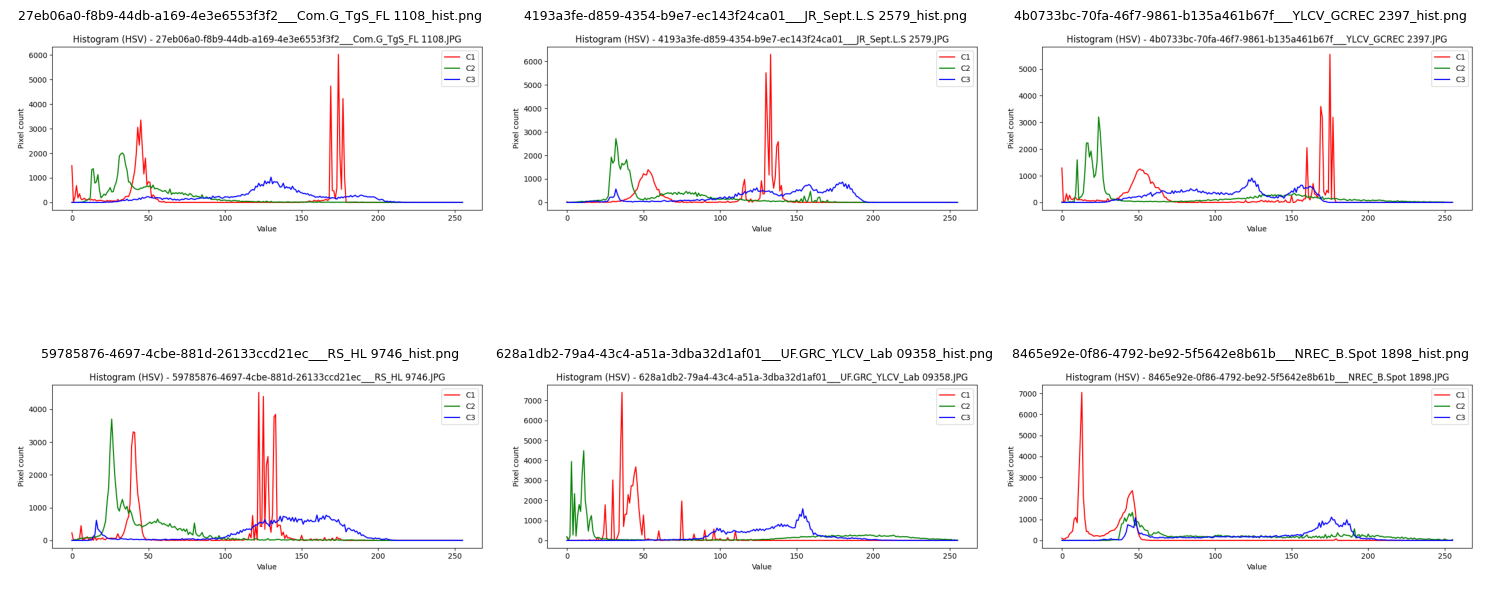

In [16]:
# Visualiser quelques histogrammes generes
hist_files = sorted(HIST_DIR.glob('*.png'))[:6]

if not hist_files:
    print('No histograms found. Run preprocessing cell first.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()

    for i, ax in enumerate(axes):
        if i < len(hist_files):
            img = cv2.imread(str(hist_files[i]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(hist_files[i].name, fontsize=9)
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()